In [1]:
import sys, os, io, pickle, warnings
from contextlib import redirect_stdout
warnings.filterwarnings('ignore')

# Make src/ importable
SRC = os.path.join(os.getcwd(), 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Linear, Parameter
from scipy.linalg import eigh as scipy_eigh
from tqdm.notebook import tqdm

from graph_utils import get_active_stocks, correlation_matrix, prepare_node_features

# Patch 1: WaveConv.__init__ – use CPU instead of hard-coded CUDA 
import WaveConv as _wc_module
import layer as _layer_module

_Wave_prop = _layer_module.Wave_prop
_WaveConv  = _wc_module.WaveConv

def _wavconv_init_patched(self, dataset, in_channels, out_channels, args):
    nn.Module.__init__(self)
    self.args = args
    self.lin1 = Linear(in_channels, args.hidden_channels_wave)
    self.lin2 = Linear(args.hidden_channels_wave, out_channels)
    self.toy  = False
    eigen, eigen_vector = dataset.eigenvalues, dataset.vectors
    _dev = torch.device('cpu')
    self.eigen        = eigen.to(_dev)
    self.eigen_vector = eigen_vector.to(_dev)
    N = len(self.eigen)
    self.prop     = _Wave_prop(args.K, N)
    self.dprate   = args.dprate
    self.dropout  = args.dropout
    self.Pro_Matrix = None

_WaveConv.__init__ = _wavconv_init_patched

#Patch 2: Wave_prop.forward – remove two debug print statements 
def _quiet_wave_forward(self, x, eigen, eigen_vector, kernel='haar'):
    TEMP = self.temp
    if kernel == 'haar':
        Pro_Matrix = TEMP[0] * self.Haar(eigen, scale=0)
        for i in range(1, self.translation_max):
            Pro_Matrix += TEMP[i] * self.Haar(eigen, scale=i)
    elif kernel == 'db2':
        Pro_Matrix = TEMP[0] * self.Db2(eigen, translation=0)
        for i in range(1, self.translation_max):
            Pro_Matrix += TEMP[i] * self.Db2(eigen, translation=i)
    elif kernel == 'db4':
        Pro_Matrix = TEMP[0] * self.Db4(eigen, translation=0)
        for i in range(1, self.translation_max):
            Pro_Matrix += TEMP[i] * self.Db4(eigen, translation=i)
    else:
        raise ValueError('Wavelet kernel not supported.')
    Pro_Matrix = eigen_vector @ torch.diag(Pro_Matrix) @ eigen_vector.T
    x = Pro_Matrix @ x
    return x, Pro_Matrix

_Wave_prop.forward = _quiet_wave_forward
print('Patches applied.')

Patches applied.


In [2]:
import argparse
from model import GNNStructEncoder
from utils import get_normalization

def make_grasped_args():
    args = argparse.Namespace()
    # Encoder
    args.encoder              = 'WaveNet'
    args.wave_kernel          = 'haar'
    args.K                    = 9          # wavelet bases
    args.hidden_channels_wave = 64
    args.dprate               = 0.0
    args.dropout              = 0.2
    # Decoder
    args.feat_decoder = 'Deconv'
    args.gamma        = [0.1, 1.0, 10.0]  # MUST be a list — DeconvWiener does len(gamma)
    args.dec_kernel   = 'heat'
    args.dec_aggr     = 'sum'
    args.simple_dec   = True               # dec_layer = 1
    args.gnn_layer_num = 2
    args.skip         = False
    args.large        = False
    args.beta         = 0.23383278064157817
    args.act          = 'prelu'
    args.norm         = ''
    args.drop_ratio   = 0.0
    # Loss weights
    args.lambda_loss1 = 0.0   # neighbor reconstruction
    args.lambda_loss2 = 0.5350470693780868   # feature reconstruction
    args.lambda_loss3 = 0.0   # degree
    # Anomaly score weights (used at test time)
    args.h_loss_weight       = 0.0
    args.feature_loss_weight = 1.0
    args.degree_loss_weight  = 0.0
    # Other
    args.aggregator   = 'mean'
    args.sample_size  = 10
    args.hidden_dimension = 32
    args.dataset      = 'finance'   # avoids toy-graph branch in WaveConv
    args.norm_type    = 'sym'
    return args

ARGS = make_grasped_args()
DEVICE = torch.device('cpu')
LOOKBACK_K = 21   # financial lookback (days)
print('Args ready. Device:', DEVICE)

Args ready. Device: cpu


In [3]:
class _MockDataset:
    """Thin wrapper so GNNStructEncoder / WaveConv get a .eigenvalues/.vectors object."""
    def __init__(self, eigenvalues, vectors):
        self.eigenvalues = eigenvalues
        self.vectors     = vectors


def compute_eigenbasis(A_full_np):
    """Compute sym-normalised Laplacian eigenbasis from a weighted adjacency matrix."""
    A = np.array(A_full_np, dtype=np.float64)
    A = (A + A.T) / 2
    A[A > 0] = 1.0   # binarise (consistent with decompose_graph.normalize_graph)
    deg = A.sum(axis=1)
    deg[deg == 0] = 1.0
    D_inv_sqrt = np.diag(deg ** -0.5)
    A_norm = D_inv_sqrt @ A @ D_inv_sqrt
    L = np.eye(A.shape[0]) - A_norm
    evals, evecs = scipy_eigh(L)
    return (torch.tensor(evals, dtype=torch.float32),
            torch.tensor(evecs, dtype=torch.float32))


class DailyGraphBuilder:
    def __init__(self, returns, all_stocks, stock2idx, lookback_k=21, k_neighbors=10):
        self.returns    = returns
        self.all_stocks = all_stocks
        self.stock2idx  = stock2idx
        self.N          = len(all_stocks)
        self.K          = lookback_k
        self.kn         = k_neighbors

    def build(self, t, feature_dfs=None):
        active = get_active_stocks(
            self.returns, t,
            lookback_days=int(self.K * 1.5),
            feature_dfs=feature_dfs,
            min_obs=self.K
        )
        if len(active) < 2:
            return None

        corr, active_cols = correlation_matrix(self.returns, t, self.K, active=active)
        n_local = len(active_cols)

        # Build local top-k unsigned adjacency, then embed into N x N global space
        C = corr.copy()
        np.fill_diagonal(C, 0.0)
        A_full = np.zeros((self.N, self.N), dtype=np.float32)

        for i_loc in range(n_local):
            gi = self.stock2idx[active_cols[i_loc]]
            abs_c = np.abs(C[i_loc])
            k = min(self.kn, n_local - 1)
            top_k = np.argpartition(abs_c, -k)[-k:]
            for j_loc in top_k:
                gj = self.stock2idx[active_cols[j_loc]]
                A_full[gi, gj] = float(np.abs(corr[i_loc, j_loc]))

        # Symmetrize
        A_full = (A_full + A_full.T) / 2

        # Build edge list: correlation edges + self-loops for ALL N nodes
        rows, cols_arr = np.nonzero(A_full)
        src_list = rows.tolist() + list(range(self.N))
        dst_list = cols_arr.tolist() + list(range(self.N))

        edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)

        # neighbor_dict (source -> list of destinations)
        neighbor_dict = {i: [] for i in range(self.N)}
        for u, v in zip(src_list, dst_list):
            neighbor_dict[u].append(v)

        neighbor_num_list = torch.tensor(
            [len(neighbor_dict[i]) for i in range(self.N)], dtype=torch.long
        )

        global_idx = torch.tensor(
            [self.stock2idx[s] for s in active_cols], dtype=torch.long
        )

        return {
            'active_cols':        active_cols,
            'global_idx':         global_idx,
            'edge_index':         edge_index,
            'A_full':             A_full,
            'neighbor_dict':      neighbor_dict,
            'neighbor_num_list':  neighbor_num_list,
        }

In [4]:
def inject_eigenbasis(model, eigenvalues, eigenvectors, device):
    """Overwrite WaveConv eigen attributes before each day's forward pass."""
    for conv in (model.graphconv1, model.graphconv2):
        conv.eigen        = eigenvalues.to(device)
        conv.eigen_vector = eigenvectors.to(device)


def build_norm_edges(edge_index, N, device):
    """Return (sym edge_index/weight, rw edge_index/weight) on device."""
    ei_sym, ew_sym = get_normalization(
        edge_index.cpu(), N, improved=1.0, dtype=torch.float32, norm='sym', laplacian=False
    )
    ei_rw, ew_rw = get_normalization(
        edge_index.cpu(), N, improved=1.0, dtype=torch.float32, norm='rw', laplacian=False
    )
    return (ei_sym.to(device), ew_sym.to(device),
            ei_rw.to(device),  ew_rw.to(device))


def prepare_full_X(active_cols, global_idx, N, Z_DATA, t, device):
    """Build N x F feature tensor; inactive nodes get zeros."""
    x_active = prepare_node_features(active_cols, Z_DATA, t)   # n_active x F
    F_dim = x_active.shape[1]
    X = torch.zeros(N, F_dim, dtype=torch.float32)
    X[global_idx] = x_active
    return X.to(device)


def _safe_norm(v):
    mn, mx = v.min(), v.max()
    return (v - mn) / (mx - mn + 1e-12)


class EarlyStopping:
    def __init__(self, patience=5, save_path='outputs/grasped_model.pt', init_best_loss=float('inf')):
        self.patience  = patience
        self.save_path = save_path
        self.best_loss = init_best_loss
        self.counter   = 0
        self.stop      = False

    def __call__(self, val_loss, model, optimizer=None):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
            ckpt = {'model': model.state_dict()}
            if optimizer is not None:
                ckpt['optimizer'] = optimizer.state_dict()
            torch.save(ckpt, self.save_path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


def load_checkpoint(save_path, model, optimizer=None):
    ckpt = torch.load(save_path)
    if isinstance(ckpt, dict) and 'model' in ckpt:
        model.load_state_dict(ckpt['model'])
        if optimizer is not None and 'optimizer' in ckpt:
            optimizer.load_state_dict(ckpt['optimizer'])
    else:
        model.load_state_dict(ckpt)


print('Helpers defined.')

Helpers defined.


In [5]:
# Load prices
prices = pd.read_excel('SPX_sectors_data.xlsx', header=[0, 1], index_col=0)
prices.dropna(how='all', inplace=True)
prices = prices.ffill().bfill()
prices.columns = prices.columns.droplevel(1)

all_stocks = prices.columns.tolist()
stock2idx  = {s: i for i, s in enumerate(all_stocks)}
idx2stock  = {i: s for s, i in stock2idx.items()}
N_FULL     = len(all_stocks)
print(f'Universe: {N_FULL} stocks')

# Returns 
returns = prices.pct_change().dropna(how='all')

train_returns = returns.loc['2012-01-01':'2016-12-31'].ffill().bfill()
val_returns   = returns.loc['2017-01-01':'2019-06-30']
test_returns  = returns.loc['2019-07-01':'2024-12-31'].ffill().bfill()

#Date splits 
K = LOOKBACK_K
min_train = train_returns.index[0] + pd.Timedelta(days=K * 2)
train_dates = train_returns.loc[min_train:].index

val_dates  = val_returns.index

min_test   = test_returns.index[0] + pd.Timedelta(days=K * 2)
test_dates = test_returns.loc[min_test:].index

print(f'Train: {len(train_dates)} days | Val: {len(val_dates)} days | Test: {len(test_dates)} days')

# Helper to load factor CSV files 
def load_and_fix_index(path):
    df = pd.read_csv(path, index_col=0)
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    return df

#Factor data 
Market_caps  = load_and_fix_index('Data/SPX_Constituents_market_cap_2006_2025(in).csv')
PE_ratios    = load_and_fix_index('Data/SPX_Constituents_Calculated_PE_2006_2025(in).csv')
Implied_vol  = load_and_fix_index('Data/SPX_Constituents_Implied_vol_2006_2025(in).csv')
Beta         = load_and_fix_index('Data/SPX_Constituents_Beta_2006_2025(in).csv')
RSI_momentum = load_and_fix_index('Data/SPX_Constituents_RSI_momentum_2006_2025(in).csv')
Turnover     = load_and_fix_index('Data/SPX_Constituents_Turnover_30D_2006_2025(in).csv')

train_volatility = train_returns.rolling(window=21).std().dropna(how='all') * np.sqrt(252)
test_volatility  = test_returns.rolling(window=21).std().dropna(how='all') * np.sqrt(252)
volatility = pd.concat([train_volatility, test_volatility]).sort_index()

feature_dfs_list = [volatility, Market_caps, PE_ratios, Implied_vol, Beta, RSI_momentum, Turnover]

def precompute_zscores(df, window=63):
    mu  = df.rolling(window=window, min_periods=1).mean()
    std = df.rolling(window=window, min_periods=1).std().replace(0, np.nan)
    z   = (df - mu) / std
    return z.fillna(0.0)

Z_DATA = {
    'volatility':  precompute_zscores(volatility),
    'market_caps': precompute_zscores(Market_caps),
    'pe_ratios':   precompute_zscores(PE_ratios),
    'implied_vol': precompute_zscores(Implied_vol),
    'beta':        precompute_zscores(Beta),
    'rsi':         precompute_zscores(RSI_momentum),
    'turnover':    precompute_zscores(Turnover),
}
FEATURE_DIM = len(Z_DATA)
print(f'Feature dim: {FEATURE_DIM}')

Universe: 503 stocks
Train: 1229 days | Val: 626 days | Test: 1357 days
Feature dim: 7


In [6]:
# Pre-compute eigenbasis for every date used in train / val / test.
# This avoids O(N^3) eigh inside the training loop.
from tqdm import tqdm
BUILDER = DailyGraphBuilder(returns, all_stocks, stock2idx, lookback_k=K)

all_dates = list(train_dates) + list(val_dates) + list(test_dates)
all_dates = sorted(set(all_dates))

EIGEN_CACHE = {}   # date -> (eigenvalues, eigenvectors)
GRAPH_CACHE = {}   # date -> builder result dict

print('Pre-computing graphs and eigenbases...')
for t in tqdm(all_dates):
    r = BUILDER.build(t, feature_dfs=feature_dfs_list)
    if r is None:
        continue
    GRAPH_CACHE[t] = r
    evals, evecs = compute_eigenbasis(r['A_full'])
    EIGEN_CACHE[t] = (evals, evecs)

print(f'Cache built: {len(GRAPH_CACHE)} / {len(all_dates)} dates')

Pre-computing graphs and eigenbases...


100%|██████████| 3212/3212 [07:15<00:00,  7.38it/s]

Cache built: 3212 / 3212 dates


In [7]:
import random

SEEDS = [0, 2, 4, 6]

def build_model(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    print(f'Seed set: {seed}')

    # Use a dummy representative eigenbasis for construction
    # (WaveConv stores it, but inject_eigenbasis overwrites it per day)
    _rep_t = list(GRAPH_CACHE.keys())[0]
    _rep_evals, _rep_evecs = EIGEN_CACHE[_rep_t]
    _mock_dataset = _MockDataset(_rep_evals, _rep_evecs)

    # Construction-time neighbor_num_list: one entry per node (constant degree 11 = 10 neighbors + self-loop)
    _rep_nn_list = torch.full((N_FULL,), 11, dtype=torch.long)

    model = GNNStructEncoder(
        args             = ARGS,
        dataset          = _mock_dataset,
        in_dim           = FEATURE_DIM,
        hidden_dim       = ARGS.hidden_dimension,
        layer_num        = ARGS.gnn_layer_num,
        sample_size      = ARGS.sample_size,
        device           = DEVICE,
        neighbor_num_list= _rep_nn_list,
        lambda_loss1     = ARGS.lambda_loss1, # neighbor reconstruction
        lambda_loss2     = ARGS.lambda_loss2,  # feature reconstruction
        lambda_loss3     = ARGS.lambda_loss3, # degree reconstruction
    ).to(DEVICE)

    # Two-group optimizer: smaller LR for degree decoder (matching src/train.py)
    deg_params  = list(map(id, model.degree_decoder.parameters()))
    base_params = filter(lambda p: id(p) not in deg_params, model.parameters())
    optimizer = torch.optim.Adam(
        [{'params': base_params},
         {'params': model.degree_decoder.parameters(), 'lr': 0.001946}],
        lr=0.001946, weight_decay=3e-4
    )

    total_params = sum(p.numel() for p in model.parameters())
    print(f'Model ready. Parameters: {total_params:,}')
    return model, optimizer

print(f'Seeds: {SEEDS}')

Seeds: [0, 2, 4, 6]


In [8]:
def train_grasped(
    model, optimizer, train_dates, val_dates,
    graph_cache, eigen_cache, Z_DATA,
    N, device,
    n_epochs=50, patience=7,
    save_path='outputs/grasped_model.pt',
    start_epoch=0, init_train_hist=None, init_val_hist=None,
):
    init_best = min(init_val_hist) if init_val_hist else float('inf')
    early_stop = EarlyStopping(patience=patience, save_path=save_path, init_best_loss=init_best)
    train_hist = list(init_train_hist) if init_train_hist else []
    val_hist   = list(init_val_hist)   if init_val_hist   else []

    for epoch in range(start_epoch, n_epochs):
        # Trainin
        model.train()
        epoch_loss = 0.0
        n_train    = 0

        for t in tqdm(train_dates, desc=f'Epoch {epoch+1}/{n_epochs} train', leave=False):
            r = graph_cache.get(t)
            if r is None:
                continue
            evals, evecs = eigen_cache[t]

            inject_eigenbasis(model, evals, evecs, device)

            ei_sym, ew_sym, ei_rw, ew_rw = build_norm_edges(r['edge_index'], N, device)

            X_t = prepare_full_X(
                r['active_cols'], r['global_idx'], N, Z_DATA, t, device
            )

            gt_deg = r['neighbor_num_list'].float().to(device)

            optimizer.zero_grad()
            try:
                with redirect_stdout(io.StringIO()):
                    loss, *_ = model(
                        ei_sym, ew_sym, ei_rw, ew_rw,
                        X_t, gt_deg, r['neighbor_dict']
                    )
            except (ValueError, RuntimeError):
                continue

            if torch.isnan(loss):
                continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()
            n_train    += 1

        avg_train = epoch_loss / max(n_train, 1)
        train_hist.append(avg_train)

        # ── Validation ────────────────────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        n_val    = 0

        with torch.no_grad():
            for t in tqdm(val_dates, desc=f'Epoch {epoch+1}/{n_epochs} val', leave=False):
                r = graph_cache.get(t)
                if r is None:
                    continue
                evals, evecs = eigen_cache[t]
                inject_eigenbasis(model, evals, evecs, device)

                ei_sym, ew_sym, ei_rw, ew_rw = build_norm_edges(r['edge_index'], N, device)
                X_t = prepare_full_X(
                    r['active_cols'], r['global_idx'], N, Z_DATA, t, device
                )
                gt_deg = r['neighbor_num_list'].float().to(device)

                try:
                    with redirect_stdout(io.StringIO()):
                        loss_v, *_ = model(
                            ei_sym, ew_sym, ei_rw, ew_rw,
                            X_t, gt_deg, r['neighbor_dict']
                        )
                except (ValueError, RuntimeError):
                    continue

                if not torch.isnan(loss_v):
                    val_loss += loss_v.item()
                    n_val    += 1

        avg_val = val_loss / max(n_val, 1)
        val_hist.append(avg_val)

        print(f'Epoch {epoch+1:03d} | train={avg_train:.4f} | val={avg_val:.4f}')

        early_stop(avg_val, model, optimizer)
        if early_stop.stop:
            print('Early stopping.')
            break

    load_checkpoint(save_path, model, optimizer)
    return model, train_hist, val_hist

In [9]:
# # ── Resume from checkpoint ────────────────────────────────────────────────────
# # Set RESUME_EPOCH to the last epoch that COMPLETED before the crash
# # (e.g. if it crashed during epoch 36, set this to 36).
# # train_hist_so_far / val_hist_so_far: paste the values from the print output above.
# # Leave as [] if you don't have them.

# RESUME_EPOCH = 36

# train_hist_so_far = []   # e.g. [0.123, 0.118, ...] one value per completed epoch
# val_hist_so_far   = []   # same length as train_hist_so_far

# # Reload model weights from the best checkpoint saved before the crash
# model.load_state_dict(torch.load('outputs/grasped_model.pt'))
# print('Loaded checkpoint.')

# # Fresh optimizer on top of loaded weights (momentum state not preserved, but weights are)
# deg_params  = list(map(id, model.degree_decoder.parameters()))
# base_params = filter(lambda p: id(p) not in deg_params, model.parameters())
# optimizer = torch.optim.Adam(
#     [{'params': base_params},
#      {'params': model.degree_decoder.parameters(), 'lr': 5e-3}],
#     lr=5e-4, weight_decay=3e-4
# )

# model, train_hist, val_hist = train_grasped(
#     model           = model,
#     optimizer       = optimizer,
#     train_dates     = train_dates,
#     val_dates       = val_dates,
#     graph_cache     = GRAPH_CACHE,
#     eigen_cache     = EIGEN_CACHE,
#     Z_DATA          = Z_DATA,
#     N               = N_FULL,
#     device          = DEVICE,
#     n_epochs        = 50,
#     patience        = 7,
#     save_path       = 'outputs/grasped_model.pt',
#     start_epoch     = RESUME_EPOCH,
#     init_train_hist = train_hist_so_far,
#     init_val_hist   = val_hist_so_far,
# )

In [10]:
def test_grasped(
    model, test_dates, prices,
    graph_cache, eigen_cache, Z_DATA,
    N, device
):
    """
    Returns
    -------
    results : {date: (active_cols, signals_array)}
        Same format as existing test_results pickles.
    test_prices : {date: price_series_for_active_cols}
    """
    model.eval()
    results     = {}
    test_prices = {}

    with torch.no_grad():
        for t in tqdm(test_dates, desc='Testing'):
            r = graph_cache.get(t)
            if r is None:
                continue
            evals, evecs = eigen_cache[t]
            inject_eigenbasis(model, evals, evecs, device)

            ei_sym, ew_sym, ei_rw, ew_rw = build_norm_edges(r['edge_index'], N, device)
            X_t = prepare_full_X(
                r['active_cols'], r['global_idx'], N, Z_DATA, t, device
            )
            gt_deg = r['neighbor_num_list'].float().to(device)
            
            try:
                with redirect_stdout(io.StringIO()):
                    (
                        _, _, _, _,
                        loss_per_node,
                        h_lp, deg_lp, feat_lp
                    ) = model(
                        ei_sym, ew_sym, ei_rw, ew_rw,
                        X_t, gt_deg, r['neighbor_dict']
                    )
            except (ValueError, RuntimeError):
                    continue

            # Composite anomaly score over the full N-node graph
            h_lp    = h_lp.squeeze().cpu() 
            deg_lp  = deg_lp.squeeze().cpu()
            feat_lp = feat_lp.squeeze().cpu()

            score_full = (
                ARGS.h_loss_weight       * _safe_norm(h_lp)    +
                ARGS.degree_loss_weight  * _safe_norm(deg_lp)  +
                ARGS.feature_loss_weight * _safe_norm(feat_lp)
            )

            # Slice scores for active stocks only
            active_scores = score_full[r['global_idx']].numpy()
            active_cols   = r['active_cols']

            results[t] = (active_cols, active_scores)

            # Prices for active stocks at date t
            t_pd = pd.Timestamp(t)
            if t_pd in prices.index:
                test_prices[t] = prices.loc[t_pd, active_cols]

    return results, test_prices

In [11]:
os.makedirs('outputs', exist_ok=True)

all_seed_results = {}   # seed -> {date: (active_cols, scores)}
test_prices_ref  = None

for seed in SEEDS:
    print(f'\n{"="*60}\nSEED {seed}\n{"="*60}')
    model, optimizer = build_model(seed)

    # ── Train ─────────────────────────────────────────────────────────────────
    model, train_hist, val_hist = train_grasped(
        model       = model,
        optimizer   = optimizer,
        train_dates = train_dates,
        val_dates   = val_dates,
        graph_cache = GRAPH_CACHE,
        eigen_cache = EIGEN_CACHE,
        Z_DATA      = Z_DATA,
        N           = N_FULL,
        device      = DEVICE,
        n_epochs    = 50,
        patience    = 7,
        save_path   = f'outputs/grasped_model_seed{seed}.pt'
    )

    # ── Test ──────────────────────────────────────────────────────────────────
    seed_results, seed_prices = test_grasped(
        model       = model,
        test_dates  = test_dates,
        prices      = prices,
        graph_cache = GRAPH_CACHE,
        eigen_cache = EIGEN_CACHE,
        Z_DATA      = Z_DATA,
        N           = N_FULL,
        device      = DEVICE
    )

    all_seed_results[seed] = seed_results
    if test_prices_ref is None:
        test_prices_ref = seed_prices

    print(f'Seed {seed}: {len(seed_results)} test days collected.')

# ── Average signals across seeds ──────────────────────────────────────────────
print('\nAveraging signals across seeds...')
common_dates = sorted(
    set.intersection(*[set(all_seed_results[s].keys()) for s in SEEDS])
)

avg_results = {}
for date in common_dates:
    active_cols = all_seed_results[SEEDS[0]][date][0]  # same across seeds (graph is deterministic)
    scores_stack = np.stack(
        [all_seed_results[s][date][1] for s in SEEDS], axis=0
    )  # (4, n_active)
    avg_results[date] = (active_cols, scores_stack.mean(axis=0))

# ── Save ──────────────────────────────────────────────────────────────────────
RESULTS_PATH = 'outputs/test_results_grasped_seeds_avg.pkl'
PRICES_PATH  = 'outputs/test_prices_grasped_seeds_avg.pkl'

with open(RESULTS_PATH, 'wb') as f:
    pickle.dump(avg_results, f)
with open(PRICES_PATH, 'wb') as f:
    pickle.dump(test_prices_ref, f)

print(f'Saved {len(avg_results)} averaged test days.')
print(f'Results  -> {RESULTS_PATH}')
print(f'Prices   -> {PRICES_PATH}')


SEED 0
Seed set: 0
Model ready. Parameters: 26,290


Epoch 001 | train=0.2285 | val=0.1017


Epoch 002 | train=0.1987 | val=0.0996


Epoch 003 | train=0.1942 | val=0.1041


Epoch 004 | train=0.1909 | val=0.0987


...

Epoch 019 | train=0.1825 | val=0.0898


Epoch 020 | train=0.1820 | val=0.0926


Epoch 021 | train=0.1815 | val=0.0903
Early stopping.


Testing: 100%|██████████| 1357/1357 [08:53<00:00,  2.55it/s]


Seed 6: 1357 test days collected.

Averaging signals across seeds...
Saved 1357 averaged test days.
Results  -> outputs/test_results_grasped_seeds_avg.pkl
Prices   -> outputs/test_prices_grasped_seeds_avg.pkl


In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import spearmanr
import pandas as pd
import numpy as np

def evaluate_once(
    test_results, test_prices,
    forward_window=22,
    crash_threshold=-0.15,
    top_k=10
):
    """
    Evaluate GRASPED anomaly signals.
    Returns dict with AUC-like metrics matching existing notebooks.
    """
    # test_prices may be saved as {date: Series} dict — convert to DataFrame
    if isinstance(test_prices, dict):
        price_df = pd.DataFrame(test_prices).T.sort_index()
    else:
        price_df = test_prices

    dates    = sorted(test_results.keys())

    ic_list, hit_list = [], []

    for i, t in enumerate(dates[:-forward_window]):
        active_cols, scores = test_results[t]
        t_pd    = pd.Timestamp(t)
        future  = dates[min(i + forward_window, len(dates) - 1)]
        f_pd    = pd.Timestamp(future)

        common = [s for s in active_cols
                  if s in price_df.columns
                  and t_pd in price_df.index
                  and f_pd in price_df.index]
        if len(common) < 5:
            continue

        idx_map = {s: j for j, s in enumerate(active_cols)}
        sc = np.array([scores[idx_map[s]] for s in common])

        p_now    = price_df.loc[t_pd, common].values.astype(float)
        p_future = price_df.loc[f_pd, common].values.astype(float)
        fwd_ret  = (p_future - p_now) / (p_now + 1e-9)

        ic, _ = spearmanr(sc, fwd_ret)
        if not np.isnan(ic):
            ic_list.append(ic)

        # Hit rate: top-k anomalies crash more than threshold
        top_idx   = np.argsort(sc)[-top_k:]
        hit       = np.mean(fwd_ret[top_idx] < crash_threshold)
        hit_list.append(hit)

    mean_ic  = float(np.nanmean(ic_list))  if ic_list  else float('nan')
    mean_hit = float(np.nanmean(hit_list)) if hit_list else float('nan')
    ic_ir    = float(np.nanmean(ic_list) / (np.nanstd(ic_list) + 1e-9)) if ic_list else float('nan')

    return {
        'forward_window': forward_window,
        'crash_threshold': crash_threshold,
        'mean_IC': mean_ic,
        'IC_IR': ic_ir,
        'hit_rate': mean_hit,
        'n_dates': len(ic_list),
    }


# ── Grid search over horizons and thresholds ──────────────────────────────────
forward_windows   = [10, 22]
crash_thresholds  = [-0.10, -0.15, -0.20, -0.30]
test_results  = pd.read_pickle('outputs/test_results_grasped_seeds_avg.pkl')
test_prices_out = pd.read_pickle('outputs/test_prices_grasped_seeds_avg.pkl')

rows = []
for fw in forward_windows:
    for ct in crash_thresholds:
        res = evaluate_once(test_results, test_prices_out, fw, ct)
        rows.append(res)

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))


 forward_window  crash_threshold   mean_IC     IC_IR  hit_rate  n_dates
             10            -0.10  0.005268  0.061100  0.063177     1337
             10            -0.15  0.005268  0.061100  0.023385     1337
             10            -0.20  0.005268  0.061100  0.010839     1337
             10            -0.30  0.005268  0.061100  0.002004     1337
             22            -0.10 -0.002541 -0.030718  0.117903     1313
             22            -0.15 -0.002541 -0.030718  0.058801     1313
             22            -0.20 -0.002541 -0.030718  0.031985     1313
             22            -0.30 -0.002541 -0.030718  0.008839     1313


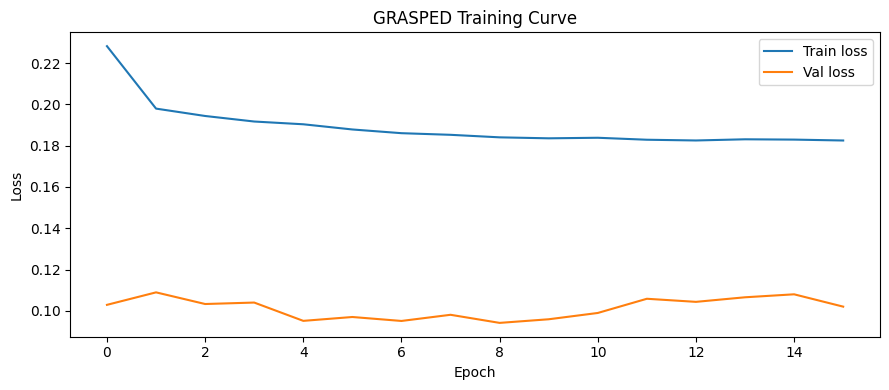

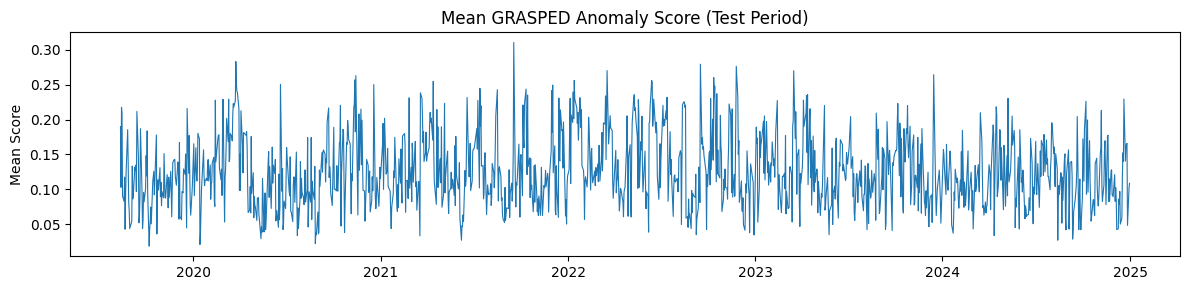

In [ ]:
# ── Training curve ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_hist, label='Train loss')
ax.plot(val_hist,   label='Val loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('GRASPED Training Curve')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/grasped_training_curve.png', dpi=150)
plt.show()

# ── Mean anomaly score over time ───────────────────────────────────────────────
dates_sorted  = sorted(test_results.keys())
mean_scores   = [np.mean(test_results[d][1]) for d in dates_sorted]

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot([pd.Timestamp(d) for d in dates_sorted], mean_scores, lw=0.8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('Mean GRASPED Anomaly Score (Test Period)')
ax.set_ylabel('Mean Score')
plt.tight_layout()
plt.savefig('outputs/grasped_signal.png', dpi=150)
plt.show()

In [6]:
from sklearn.metrics import roc_auc_score
import torch

def evaluate_once(test_results, prices, forward_window, crash_threshold):
    # prices may be saved as {Timestamp: Series} dict — convert to DataFrame
    if isinstance(prices, dict):
        prices = pd.DataFrame(prices).T.sort_index()

    y_true, y_scores = [], []
    for t in sorted(test_results.keys()):
        if t > prices.index[-1] - pd.Timedelta(days=forward_window):
            continue
        stocks, signals = test_results[t]
        if isinstance(signals, torch.Tensor):
            signals = signals.cpu().numpy()
        signals = signals.flatten()
        available = [s for s in stocks if s in prices.columns]
        if not available:
            continue
        mask = [i for i, s in enumerate(stocks) if s in available]
        signals = signals[mask]
        p_t = prices.loc[t, available]
        future_idx = prices.index.searchsorted(t + pd.Timedelta(days=forward_window))
        if future_idx >= len(prices):
            continue
        p_future = prices.loc[prices.index[future_idx], available]
        fwd_returns = (p_future - p_t) / p_t
        crash = (fwd_returns < crash_threshold).astype(int)
        y_true.extend(crash.values)
        y_scores.extend(signals)
    if not y_true:
        return None
    y_true, y_scores = np.array(y_true), np.array(y_scores)
    auc = roc_auc_score(y_true, y_scores)
    baseline = y_true.mean()
    precision = y_true[y_scores > np.percentile(y_scores, 90)].mean()
    lift = precision / baseline if baseline > 0 else np.nan
    return auc, lift, baseline, precision


def grid_search(test_results, prices, forward_windows, crash_thresholds):
    rows = []
    for fw in forward_windows:
        for ct in crash_thresholds:
            result = evaluate_once(test_results, prices, fw, ct)
            if result:
                auc, lift, baseline, precision = result
                rows.append(dict(FW=fw, CT=ct, AUC=round(auc, 3),
                                 Lift=round(lift, 2), Baseline=round(baseline, 3),
                                 Precision=round(precision, 3)))
    return pd.DataFrame(rows)


#evaluate
# test_results_g  = pd.read_pickle('outputs/test_results_grasped_04May.pkl')
# test_prices_g   = pd.read_pickle('outputs/test_prices_grasped_04May.pkl')

test_results  = pd.read_pickle('outputs/test_results_grasped_seeds_avg.pkl')
test_prices = pd.read_pickle('outputs/test_prices_grasped_seeds_avg.pkl')


df_results = grid_search(
    test_results,
    test_prices,
    forward_windows=[10, 22],
    crash_thresholds=[-0.10, -0.15, -0.20, -0.30]
)
print(df_results.to_string(index=False))


 FW    CT   AUC  Lift  Baseline  Precision
 10 -0.10 0.556  1.32     0.034      0.045
 10 -0.15 0.591  1.41     0.012      0.018
 10 -0.20 0.609  1.39     0.006      0.008
 10 -0.30 0.608  1.24     0.002      0.002
 22 -0.10 0.539  1.25     0.068      0.085
 22 -0.15 0.574  1.44     0.028      0.040
 22 -0.20 0.600  1.55     0.013      0.021
 22 -0.30 0.605  1.52     0.005      0.007


In [ ]:
# # GRASPED only using feature loss only:
#  FW    CT   AUC  Lift  Baseline  Precision
#  10 -0.10 0.508  1.04     0.034      0.035
#  10 -0.15 0.502  0.92     0.012      0.012
#  10 -0.20 0.481  0.71     0.006      0.004
#  10 -0.30 0.461  0.48     0.002      0.001
#  22 -0.10 0.525  1.13     0.068      0.076
#  22 -0.15 0.543  1.19     0.028      0.033
#  22 -0.20 0.556  1.17     0.013      0.016
#  22 -0.30 0.539  0.95     0.005      0.004

In [ ]:
# # GRASPED RESULTS WHEN using all decoders: 

#  FW    CT   AUC  Lift  Baseline  Precision
#  10 -0.10 0.490  0.97     0.037      0.036
#  10 -0.15 0.470  0.87     0.014      0.012
#  10 -0.20 0.442  0.72     0.007      0.005
#  10 -0.30 0.419  0.60     0.002      0.001
#  22 -0.10 0.514  1.05     0.072      0.075
#  22 -0.15 0.529  1.07     0.029      0.031
#  22 -0.20 0.539  1.05     0.013      0.014
#  22 -0.30 0.520  0.86     0.004      0.003